## Importar Librerías

In [36]:
# Librerías básicas
import numpy as np
import pandas as pd

# Librerías de procesamiento
from sklearn.preprocessing import MinMaxScaler

# Librerías del modelo 
from sklearn.ensemble import RandomForestClassifier

# Librerías de entrenamiento
from sklearn.model_selection import train_test_split
from sklearn import metrics 

## Import Dataset

In [37]:
df = pd.read_csv('.\\BankChurn.csv')


In [38]:
df.shape

(10127, 20)

In [39]:
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [40]:
df["Attrition_Flag"].unique()

array(['Existing Customer', 'Attrited Customer'], dtype=object)

In [41]:
df.groupby(["Attrition_Flag"]).count()

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
Attrition_Flag,,,,,,,,,,,,,,,,,,,
Attrited Customer,1627,1627,1627,1627,1627,1627,1627,1627,1627,1627,1627,1627,1627,1627,1627,1627,1627,1627,1627
Existing Customer,8500,8500,8500,8500,8500,8500,8500,8500,8500,8500,8500,8500,8500,8500,8500,8500,8500,8500,8500


In [42]:
df.describe()

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


In [43]:
# number of churn and non-churn 
counts = df.Attrition_Flag.value_counts()
perc_churn = (counts[1] / (counts[0] + counts[1])) * 100

# no. of duplicates 
duplicates = len(df[df.duplicated()])

# no of missing values
missing_values = df.isnull().sum().sum()

# Data types in dataset
types = df.dtypes.value_counts()

C:\Users\cante\AppData\Local\Temp\ipykernel_1556\2495366671.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  perc_churn = (counts[1] / (counts[0] + counts[1])) * 100


In [44]:
print("Churn Rate = %.1f %%"%(perc_churn))
print('Number of Duplicate Entries: %d'%(duplicates))
print('Number of Missing Values: %d'%(missing_values))
print('Number of Features: %d'%(df.shape[1]))
print('Number of Customers: %d'%(df.shape[0]))
print('Data Types and Frequency in Dataset:')
print(types)

Churn Rate = 16.1 %
Number of Duplicate Entries: 0
Number of Missing Values: 0
Number of Features: 20
Number of Customers: 10127
Data Types and Frequency in Dataset:
int64      9
object     6
float64    5
Name: count, dtype: int64


## Pre-Processing

In [45]:
# make gender and outcome numerical
df['Gender'] = df['Gender'].map({'M': 1, 'F': 0})
df['Attrition_Flag'] = df['Attrition_Flag'].map({'Attrited Customer': 1, 'Existing Customer': 0})


# Code adapted from: https://www.kaggle.com/code/andreshg/churn-prediction-0-99-auc-h2o-sklearn-smote#2.-Feature-Engeneering
catcols = df.select_dtypes(exclude = ['int64','float64']).columns
intcols = df.select_dtypes(include = ['int64']).columns
floatcols = df.select_dtypes(include = ['float64']).columns

# one-hot encoding on categorical columns
df = pd.get_dummies(df, columns = catcols)

# minmax scaling numeric features 
for col in df[floatcols]:
    df[col] = MinMaxScaler().fit_transform(df[[col]])
    
for col in df[intcols]:
    df[col] = MinMaxScaler().fit_transform(df[[col]])
    
print('New Number of Features: %d'%(df.shape[1]))  

New Number of Features: 37


In [46]:
# split into X and y
X = df.drop('Attrition_Flag', axis = 1)
y = df['Attrition_Flag']

In [47]:
display(X)

,Customer_Age,Gender,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,...,Income_Category_$120K +,Income_Category_$40K - $60K,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Income_Category_Unknown,Card_Category_Blue,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
0,0.404255,1.0,0.6,0.604651,0.8,0.166667,0.500000,0.340190,0.308701,0.345116,...,False,False,True,False,False,False,True,False,False,False
1,0.489362,0.0,1.0,0.720930,1.0,0.166667,0.333333,0.206112,0.343266,0.214093,...,False,False,False,False,True,False,True,False,False,False
2,0.531915,1.0,0.6,0.534884,0.6,0.166667,0.000000,0.059850,0.000000,0.098948,...,False,False,False,True,False,False,True,False,False,False
3,0.297872,0.0,0.8,0.488372,0.4,0.666667,0.166667,0.056676,1.000000,0.022977,...,False,False,False,False,True,False,True,False,False,False
4,0.297872,1.0,0.6,0.186047,0.8,0.166667,0.000000,0.099091,0.000000,0.136557,...,False,False,True,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,0.510638,1.0,0.4,0.627907,0.4,0.333333,0.500000,0.077536,0.735399,0.062266,...,False,True,False,False,False,False,True,False,False,False
10123,0.319149,1.0,0.4,0.279070,0.6,0.333333,0.500000,0.085819,0.868494,0.060499,...,False,True,False,False,False,False,True,False,False,False
10124,0.382979,0.0,0.2,0.534884,0.8,0.500000,0.666667,0.120042,0.000000,0.156637,...,False,False,False,False,True,False,True,False,False,False
10125,0.085106,1.0,0.4,0.534884,0.6,0.500000,0.500000,0.116172,0.000000,0.152928,...,False,True,False,False,False,False,True,False,False,False


## Feature Selection

In [48]:
# the selected variables
FEATURES = [
    'Customer_Age', 
    'Total_Amt_Chng_Q4_Q1', 
    'Total_Relationship_Count', 
    'Total_Revolving_Bal', 
    'Total_Ct_Chng_Q4_Q1', 
    'Total_Trans_Ct', 
    'Total_Trans_Amt', 
    'Months_Inactive_12_mon', 
    'Contacts_Count_12_mon'
    ]


## Train model

In [49]:
forest = RandomForestClassifier(n_estimators = 850, max_depth = 19, random_state = 1200)

In [50]:
X_new = X[FEATURES]

train_x, test_x, train_y, test_y = train_test_split(X_new, y, test_size = 0.25, random_state = 42)
    
forest.fit(train_x,train_y)
forest.score(test_x, test_y)
pred_test = forest.predict(test_x)
    
f1 = metrics.f1_score(test_y, pred_test)
test_acc = metrics.accuracy_score(test_y, pred_test)
con = metrics.confusion_matrix(test_y, pred_test)
precision = metrics.precision_score(test_y, pred_test)
recall = metrics.recall_score(test_y, pred_test)
roc = metrics.roc_auc_score(test_y, pred_test)

In [51]:
pred_test[0]

np.float64(0.0)

In [52]:
type(pred_test[0])

numpy.float64

In [53]:
print('Accuracy Score', test_acc)
print('Precision', precision)
print('Recall', recall)
print('F1-Score', f1)
print('ROC Score', roc)
print(con)

Accuracy Score 0.9664296998420221
Precision 0.9304123711340206
Recall 0.8615751789976134
F1-Score 0.8946716232961586
ROC Score 0.9243985691485936
[[2086   27]
 [  58  361]]


In [54]:
#cross validation
from sklearn.model_selection import cross_validate 

cv_results = cross_validate(forest, X_new, y, scoring = ('f1', 'accuracy', 'roc_auc'), cv = 8)
sorted(cv_results.keys())

['fit_time', 'score_time', 'test_accuracy', 'test_f1', 'test_roc_auc']

In [55]:
cv_results['test_roc_auc'] 

array([0.91056078, 0.96866615, 0.98541168, 0.9918462 , 0.99539807,
       0.99796213, 0.8989536 , 0.90523967])

In [56]:
cv_results['test_f1'] 

array([0.60892388, 0.82324455, 0.89047619, 0.8814433 , 0.89189189,
       0.921875  , 0.78450363, 0.74285714])

In [57]:
cv_results['test_accuracy'] 

array([0.88230648, 0.94233807, 0.96366509, 0.96366509, 0.96840442,
       0.97630332, 0.92969984, 0.92885375])

In [58]:
import matplotlib.pyplot as plt

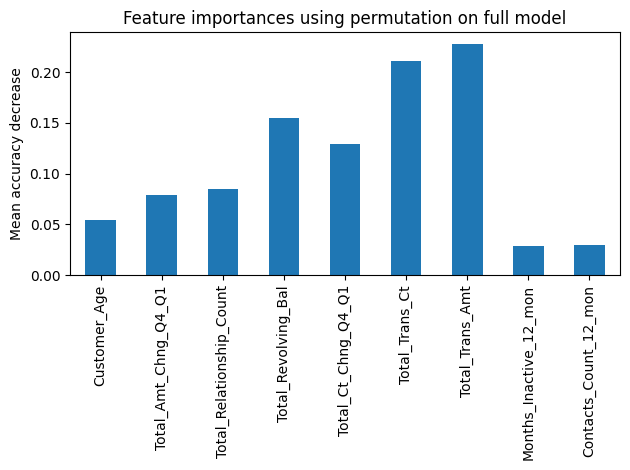

In [59]:
forest_importances = pd.Series(forest.feature_importances_, index=FEATURES)
fig, ax = plt.subplots()
forest_importances.plot.bar(ax=ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()

## Train simpler model (3 features)

In [60]:
FEATURES_SIMPLE = [
    'Total_Trans_Ct', 
    'Total_Trans_Amt',
    'Total_Revolving_Bal']

In [61]:
forest_simple = RandomForestClassifier(n_estimators = 850, max_depth = 19, random_state = 1200)

In [62]:
X_simple = X[FEATURES_SIMPLE]

train_x_simple, test_x_simple, train_y_simple, test_y_simple = train_test_split(X_simple, y, test_size = 0.25, random_state = 42)
    
forest_simple.fit(train_x_simple,train_y_simple)
forest_simple.score(test_x_simple, test_y_simple)
pred_test = forest_simple.predict(test_x_simple)
    
f1 = metrics.f1_score(test_y_simple, pred_test)
test_acc = metrics.accuracy_score(test_y_simple, pred_test)
con = metrics.confusion_matrix(test_y_simple, pred_test)
precision = metrics.precision_score(test_y_simple, pred_test)
recall = metrics.recall_score(test_y_simple, pred_test)
roc = metrics.roc_auc_score(test_y, pred_test)

In [63]:
print('Accuracy Score (simple)', test_acc)
print('Precision (simple)', precision)
print('Recall (simple)', recall)
print('F1-Score (simple)', f1)
print('ROC Score (simple)', roc)
print(con)

Accuracy Score (simple) 0.9214060031595577
Precision (simple) 0.8072625698324022
Recall (simple) 0.6897374701670644
F1-Score (simple) 0.7438867438867439
ROC Score (simple) 0.8285412386329879
[[2044   69]
 [ 130  289]]


In [64]:
#cross validation
from sklearn.model_selection import cross_validate 

cv_results_simple = cross_validate(forest_simple, X_simple, y, scoring = ('f1', 'accuracy', 'roc_auc'), cv = 8)
sorted(cv_results_simple.keys())

['fit_time', 'score_time', 'test_accuracy', 'test_f1', 'test_roc_auc']

In [65]:
cv_results_simple['test_roc_auc'] 

array([0.84363893, 0.82392986, 0.94305548, 0.97798081, 0.9912831 ,
       0.99287323, 0.92813919, 0.86004193])

In [66]:
cv_results_simple['test_f1'] 

array([0.37735849, 0.50309278, 0.70559611, 0.75706215, 0.8       ,
       0.80911681, 0.63522013, 0.74626866])

In [67]:
cv_results_simple['test_accuracy'] 

array([0.81753555, 0.80963665, 0.90442338, 0.93206951, 0.94391785,
       0.94707741, 0.90837283, 0.91936759])